In [1]:
!pip install -q torchinfo

In [78]:
import os
import random
import numpy as np
from collections import defaultdict
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from scipy import linalg
import pandas as pd

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
sns.set_style('darkgrid')

print("All libraries imported!")

All libraries imported!


In [2]:
import os
import time
import json
import random
import numpy as np
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchinfo import summary

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')

# Pretty plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
sns.set_style('darkgrid')

print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/Colab_Notebooks/VAE/vae_fingerprints'
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)
print(f"Drive project directory: {DRIVE_PROJECT_DIR}")

Drive project directory: /content/drive/MyDrive/Colab_Notebooks/VAE/vae_fingerprints


In [5]:
def download_and_extract_dataset(dest_dir='./dataset'):
    """
    Automatically download and extract the SOCOFing dataset from Kaggle.
    Uses gdown for Google Drive mirror if direct download fails.
    """
    real_dir = os.path.join(dest_dir, 'Real')
    if os.path.isdir(real_dir) and len(os.listdir(real_dir)) > 100:
        print(f"Dataset already exists at {dest_dir} ({len(os.listdir(real_dir))} files)")
        return

    print("Downloading SOCOFing dataset...")
    os.makedirs(dest_dir, exist_ok=True)

    # Try Kaggle CLI first
    try:
        import subprocess
        subprocess.run(['pip', 'install', '-q', 'kaggle'], check=True)
        # Set Kaggle credentials if available
        kaggle_dir = os.path.expanduser('~/.kaggle')
        os.makedirs(kaggle_dir, exist_ok=True)
        subprocess.run([
            'kaggle', 'datasets', 'download', '-d', 'ruizgara/socofing',
            '-p', dest_dir, '--unzip'
        ], check=True)
        # SOCOFing extracts with a nested folder structure
        nested = os.path.join(dest_dir, 'SOCOFing')
        if os.path.isdir(nested):
            for item in os.listdir(nested):
                src = os.path.join(nested, item)
                dst = os.path.join(dest_dir, item)
                if not os.path.exists(dst):
                    os.rename(src, dst)
        print("Dataset downloaded via Kaggle!")
        return
    except Exception as e:
        print(f"   Kaggle download failed ({e}), trying alternative...")

    # Alternative: gdown from a public Google Drive mirror
    try:
        subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
        import gdown
        url = 'https://drive.google.com/uc?id=1VG3yL1M-cQpIF7WRXZ3KJcaaqBb9Cxya'
        zip_path = os.path.join(dest_dir, 'SOCOFing.zip')
        gdown.download(url, zip_path, quiet=False)
        import zipfile
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(dest_dir)
        os.remove(zip_path)
        # Handle nested extraction
        nested = os.path.join(dest_dir, 'SOCOFing')
        if os.path.isdir(nested):
            for item in os.listdir(nested):
                src = os.path.join(nested, item)
                dst = os.path.join(dest_dir, item)
                if not os.path.exists(dst):
                    os.rename(src, dst)
        print("Dataset downloaded via gdown!")
    except Exception as e:
        print(f"Auto-download failed: {e}")
        print("Please manually upload the SOCOFing dataset to ./dataset/Real/")
        print("Download from: https://www.kaggle.com/datasets/ruizgara/socofing")


In [6]:
download_and_extract_dataset('./dataset')

Dataset already exists at ./dataset (6000 files)


In [7]:
def setup_device():
    """Setup the best available device: GPU > CPU"""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        device_name = torch.cuda.get_device_name(0)
        print(f"Using GPU: {device_name}")
        return device, device_name

    device = torch.device('cpu')
    device_name = "CPU"
    print(f"Using CPU (training will be slow)")
    return device, device_name

In [8]:
DEVICE, DEVICE_NAME = setup_device()

Using GPU: Tesla T4


In [52]:
class Config:
    """All hyperparameters and paths in one place.
    Optimized for Google Colab T4/V100 GPU (~3 hour training budget).
    """

    # === Paths (Google Drive integrated) ===
    DATASET_ROOT = './dataset'
    REAL_DIR = os.path.join(DATASET_ROOT, 'Real')
    ALTERED_DIR = os.path.join(DATASET_ROOT, 'Altered')
    # Checkpoints & results saved to Drive for persistence
    CHECKPOINT_DIR = os.path.join(DRIVE_PROJECT_DIR, 'checkpoints')
    RESULTS_DIR = os.path.join(DRIVE_PROJECT_DIR, 'results')

    # === Image Settings ===
    IMG_SIZE = 128          # Resize to 128x128 for clean conv arithmetic
    IMG_CHANNELS = 1        # Grayscale fingerprints

    # === Model Architecture ===
    LATENT_DIM = 256       # Dimensionality of the latent space
    ENCODER_CHANNELS = [32, 64, 128, 256, 512]   # Encoder conv channels
    DECODER_CHANNELS = [512, 256, 128, 64, 32]    # Decoder deconv channels

    # === Training Hyperparameters (GPU-optimized) ===
    BATCH_SIZE = 64         # Batch size (fits Colab T4 16GB)
    NUM_EPOCHS = 200         # Optimized to complete within ~3 hours
    LEARNING_RATE = 5e-4   # Initial learning rate
    WEIGHT_DECAY = 1e-5     # L2 regularization
    LR_MIN = 1e-6           # Minimum learning rate for scheduler

    # === KL Annealing (β-VAE style warmup) ===
    KL_ANNEAL_EPOCHS = 80   # Warmup KL weight over this many epochs
    KL_WEIGHT_MAX = 0.1     # Maximum KL weight (4.0 )

    # === Checkpointing (every 2 epochs to Drive) ===
    CHECKPOINT_EVERY = 2    # Save checkpoint every 2 epochs
    SAVE_BEST = True        # Save best model based on val loss

    # === Data Split (train / val / test) ===
    TRAIN_RATIO = 0.80      # 80% train
    VAL_RATIO = 0.10        # 10% validation
    TEST_RATIO = 0.10       # 10% test (held out for Part 2)
    NUM_WORKERS = 0       # DataLoader workers
    PIN_MEMORY = True       # Pin memory for faster CUDA transfer

    FREE_BITS = 0.1  # per dim, 0.5 × 64 = 32 minimum
    # === Reproducibility ===
    SEED = 42


In [53]:
config = Config()

In [54]:
os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(config.RESULTS_DIR, exist_ok=True)

print("Configuration:")
print(f"Dataset:{config.DATASET_ROOT}")
print(f"Checkpoints:{config.CHECKPOINT_DIR} (Google Drive)")
print(f"Results:{config.RESULTS_DIR} (Google Drive)")
print(f"Image size:{config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Latent dim:{config.LATENT_DIM}")
print(f"Batch size:{config.BATCH_SIZE}")
print(f"Epochs:{config.NUM_EPOCHS}")
print(f"Checkpoint:Every {config.CHECKPOINT_EVERY} epochs")
print(f"LR:{config.LEARNING_RATE}")

Configuration:
Dataset:./dataset
Checkpoints:/content/drive/MyDrive/Colab_Notebooks/VAE/vae_fingerprints/checkpoints (Google Drive)
Results:/content/drive/MyDrive/Colab_Notebooks/VAE/vae_fingerprints/results (Google Drive)
Image size:128x128
Latent dim:256
Batch size:64
Epochs:200
Checkpoint:Every 2 epochs
LR:0.0005


In [12]:
def set_seed(seed):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [13]:
set_seed(config.SEED)
print(f"Random seed set to {config.SEED}")

Random seed set to 42


In [14]:
class SOCOFingDataset(Dataset):
    """
    Custom Dataset for SOCOFing fingerprint images.
    Extracts metadata (subject_id, gender, hand, finger) from filenames.
    Filename pattern: {id}__{gender}_{hand}_{finger}_finger.BMP
    """

    def __init__(self, root_dir, transform=None, subset='Real'):
        self.root_dir = root_dir
        self.transform = transform
        self.subset = subset

        self.image_paths = []
        self.metadata = []   # List of dicts with parsed info

        if subset == 'Real':
            self._load_real(root_dir)
        elif subset == 'All':
            # Load Real + all Altered
            real_dir = os.path.join(root_dir, 'Real')
            altered_dir = os.path.join(root_dir, 'Altered')
            if os.path.isdir(real_dir):
                self._load_real(real_dir)
            if os.path.isdir(altered_dir):
                for alt_type in ['Altered-Easy', 'Altered-Medium', 'Altered-Hard']:
                    alt_path = os.path.join(altered_dir, alt_type)
                    if os.path.isdir(alt_path):
                        self._load_altered(alt_path, alt_type)
        else:
            self._load_real(root_dir)

        print(f"   Loaded {len(self.image_paths)} images from [{subset}]")

    def _parse_filename(self, filename):
        """Parse SOCOFing filename to extract metadata"""
        # Pattern: {id}__{gender}_{hand}_{finger}_finger.BMP
        # Some altered: {id}__{gender}_{hand}_{finger}_finger_{alteration}.BMP
        name = os.path.splitext(filename)[0]  # Remove extension
        parts = name.split('_')

        meta = {
            'subject_id': -1,
            'gender': 'Unknown',
            'hand': 'Unknown',
            'finger': 'Unknown',
        }

        try:
            # Find the subject ID (first element before double underscore)
            meta['subject_id'] = int(parts[0])

            # Find gender (M or F) — it's after the empty string from __
            for i, p in enumerate(parts):
                if p in ('M', 'F'):
                    meta['gender'] = p
                    # Next part is hand
                    if i + 1 < len(parts):
                        meta['hand'] = parts[i + 1]
                    # Next part is finger type
                    if i + 2 < len(parts):
                        meta['finger'] = parts[i + 2]
                    break
        except (ValueError, IndexError):
            pass

        return meta

    def _load_real(self, directory):
        """Load images from a single directory"""
        if not os.path.isdir(directory):
            print(f"   ⚠️  Directory not found: {directory}")
            return

        valid_ext = ('.bmp', '.BMP', '.png', '.PNG', '.jpg', '.JPG', '.jpeg')
        for fname in sorted(os.listdir(directory)):
            if fname.endswith(valid_ext):
                fpath = os.path.join(directory, fname)
                meta = self._parse_filename(fname)
                meta['source'] = 'Real'
                self.image_paths.append(fpath)
                self.metadata.append(meta)

    def _load_altered(self, directory, alt_type):
        """Load altered images"""
        if not os.path.isdir(directory):
            return
        valid_ext = ('.bmp', '.BMP', '.png', '.PNG', '.jpg', '.JPG', '.jpeg')
        for fname in sorted(os.listdir(directory)):
            if fname.endswith(valid_ext):
                fpath = os.path.join(directory, fname)
                meta = self._parse_filename(fname)
                meta['source'] = alt_type
                self.image_paths.append(fpath)
                self.metadata.append(meta)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        # Load image as grayscale
        try:
            image = Image.open(img_path).convert('L')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return a blank image if loading fails
            image = Image.new('L', (config.IMG_SIZE, config.IMG_SIZE), 128)

        if self.transform:
            image = self.transform(image)

        meta = self.metadata[idx]
        return image, meta


In [15]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5], std=[0.5]),  # → [-1, 1]
])

val_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5], std=[0.5]),  # → [-1, 1]
])

In [16]:
print("Loading SOCOFing Dataset...")

# Create two separate dataset objects so train and val get different transforms
train_full = SOCOFingDataset(root_dir=config.REAL_DIR, transform=train_transform, subset='Real')
val_full   = SOCOFingDataset(root_dir=config.REAL_DIR, transform=val_transform,   subset='Real')

# Compute split sizes
total_size = len(train_full)
train_size = int(config.TRAIN_RATIO * total_size)
val_size   = int(config.VAL_RATIO   * total_size)
test_size  = total_size - train_size - val_size

# Split using identical seeds so indices match across both datasets
split_gen = torch.Generator().manual_seed(config.SEED)
train_dataset, _, _ = random_split(train_full, [train_size, val_size, test_size], generator=split_gen)

split_gen = torch.Generator().manual_seed(config.SEED)  # reset seed — critical!
_, val_dataset, test_dataset = random_split(val_full, [train_size, val_size, test_size], generator=split_gen)

print(f"\nDataset Split:")
print(f"Total: {total_size} images")
print(f"Training:   {train_size} ({config.TRAIN_RATIO*100:.0f}%)")
print(f"Validation: {val_size}   ({config.VAL_RATIO*100:.0f}%)")
print(f"Test:       {test_size}  ({config.TEST_RATIO*100:.0f}%)")

Loading SOCOFing Dataset...
   Loaded 6000 images from [Real]
   Loaded 6000 images from [Real]

Dataset Split:
Total: 6000 images
Training:   4800 (80%)
Validation: 600   (10%)
Test:       600  (10%)


In [17]:
split_info = {
    'train_indices': train_dataset.indices,
    'val_indices': val_dataset.indices,
    'test_indices': test_dataset.indices,
    'total_size': total_size,
}
torch.save(split_info, os.path.join(config.CHECKPOINT_DIR, 'data_split_indices.pt'))
print(f"Split indices saved to Drive")


Split indices saved to Drive


In [85]:
# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    pin_memory=config.PIN_MEMORY,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    pin_memory=config.PIN_MEMORY,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    pin_memory=config.PIN_MEMORY,
    drop_last=False
)



In [19]:
print(f"DataLoaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

DataLoaders created:
Train batches: 75
Val batches: 10
Test batches: 10


In [20]:
def visualize_samples(dataset, num_samples=10, title="Sample Fingerprints"):
    """Visualize random samples from the dataset"""
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    for i, idx in enumerate(indices):
        row, col = i // 5, i % 5
        img, meta = dataset[idx]

        if isinstance(img, torch.Tensor):
            img_np = img.squeeze().numpy()
        else:
            img_np = np.array(img)

        axes[row, col].imshow(img_np, cmap='gray')
        label = f"ID:{meta['subject_id']} {meta['gender']}\n{meta['hand']} {meta['finger']}"
        axes[row, col].set_title(label, fontsize=8)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'sample_fingerprints.png'), dpi=150, bbox_inches='tight')
    plt.show()

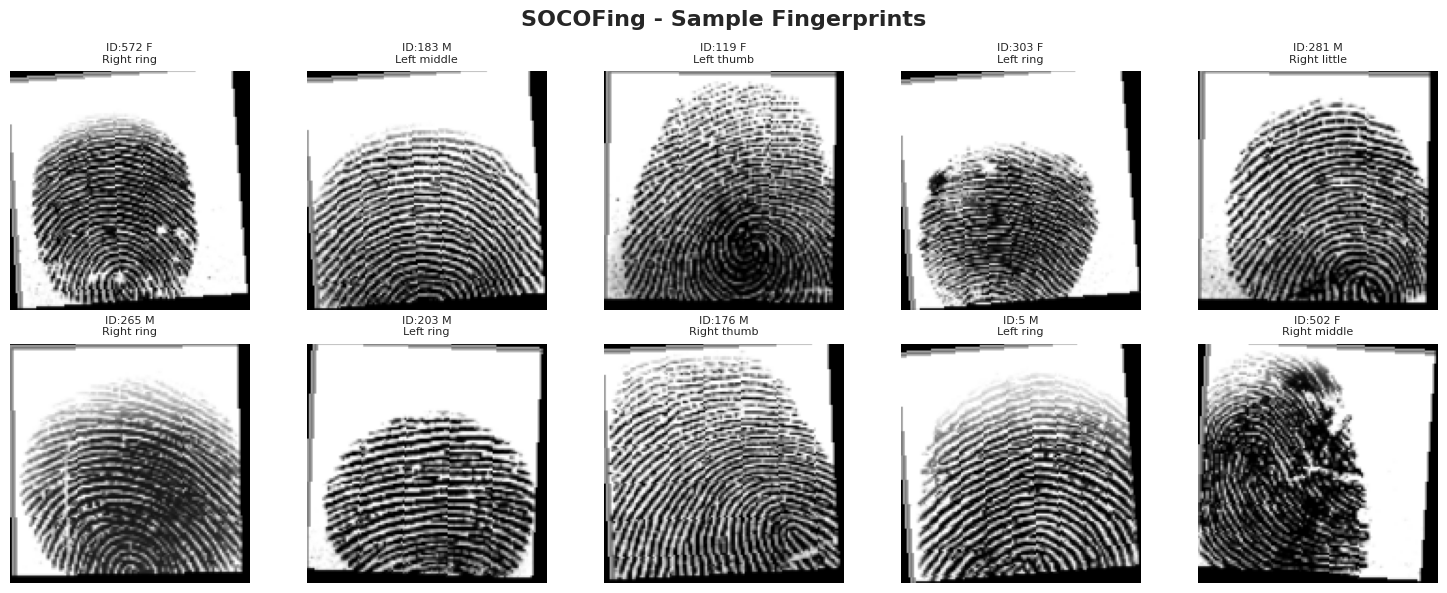

In [21]:
visualize_samples(train_full, num_samples=10, title="SOCOFing - Sample Fingerprints")

In [22]:
def dataset_statistics(dataset):
    """Print dataset statistics"""
    genders = defaultdict(int)
    fingers = defaultdict(int)
    hands = defaultdict(int)

    for meta in dataset.metadata:
        genders[meta['gender']] += 1
        fingers[meta['finger']] += 1
        hands[meta['hand']] += 1

    print("Dataset Statistics:")
    print(f"\nGender Distribution:")
    for k, v in sorted(genders.items()):
        print(f"{k}: {v} ({v/len(dataset)*100:.1f}%)")

    print(f"\n   Finger Distribution:")
    for k, v in sorted(fingers.items()):
        print(f"{k}: {v} ({v/len(dataset)*100:.1f}%)")

    print(f"\nHand Distribution:")
    for k, v in sorted(hands.items()):
        print(f"{k}: {v} ({v/len(dataset)*100:.1f}%)")

    # Plot distributions
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].bar(genders.keys(), genders.values(), color=['#4ECDC4', '#FF6B6B'])
    axes[0].set_title('Gender Distribution', fontweight='bold')
    axes[0].set_ylabel('Count')

    axes[1].bar(fingers.keys(), fingers.values(), color='#45B7D1')
    axes[1].set_title('Finger Type Distribution', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)

    axes[2].bar(hands.keys(), hands.values(), color=['#96CEB4', '#FFEAA7'])
    axes[2].set_title('Hand Distribution', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'dataset_statistics.png'), dpi=150, bbox_inches='tight')
    plt.show()


Dataset Statistics:

Gender Distribution:
F: 1230 (20.5%)
M: 4770 (79.5%)

   Finger Distribution:
index: 1200 (20.0%)
little: 1200 (20.0%)
middle: 1200 (20.0%)
ring: 1200 (20.0%)
thumb: 1200 (20.0%)

Hand Distribution:
Left: 3000 (50.0%)
Right: 3000 (50.0%)


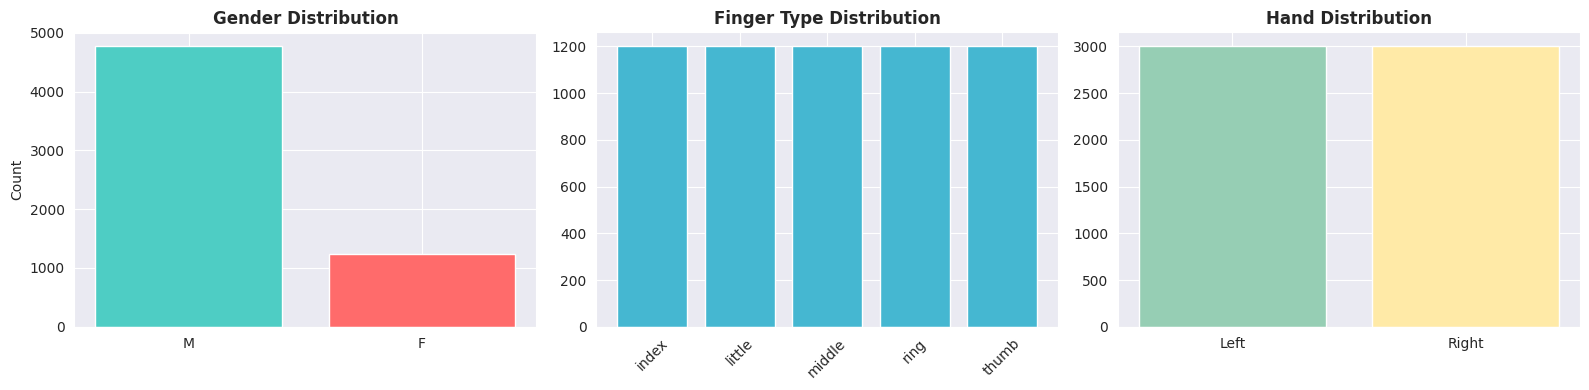

In [23]:
dataset_statistics(train_full)

In [24]:
class Encoder(nn.Module):
    """
    Convolutional Encoder for VAE.
    Maps input image x to latent parameters (μ, log_σ²).

    Architecture (for 128x128 input):
        Conv(1→32, 4, 2, 1)  → 64x64
        Conv(32→64, 4, 2, 1) → 32x32
        Conv(64→128, 4, 2, 1)→ 16x16
        Conv(128→256,4, 2, 1)→ 8x8
        Conv(256→512,4, 2, 1)→ 4x4
        Flatten → FC → μ, log_σ²
    """

    def __init__(self, in_channels=1, latent_dim=128, channels=[32, 64, 128, 256, 512]):
        super(Encoder, self).__init__()

        layers = []
        prev_ch = in_channels

        for ch in channels:
            layers.extend([
                nn.Conv2d(prev_ch, ch, kernel_size=4, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(ch),
                nn.LeakyReLU(0.2, inplace=True),
            ])
            prev_ch = ch

        self.conv_layers = nn.Sequential(*layers)

        # After 5 convolutions with stride 2: 128 → 4
        # Flatten: 512 * 4 * 4 = 8192
        self.flatten_size = channels[-1] * 4 * 4

        # Latent space projections
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)

    def forward(self, x):
        h = self.conv_layers(x)
        h = h.view(h.size(0), -1)   # Flatten
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar



In [25]:
class Decoder(nn.Module):
    """
    Convolutional Decoder for VAE.
    Reconstructs image x̂ from latent vector z.

    Architecture:
        FC → Reshape to 512x4x4
        DeConv(512→256, 4, 2, 1) → 8x8
        DeConv(256→128, 4, 2, 1) → 16x16
        DeConv(128→64, 4, 2, 1)  → 32x32
        DeConv(64→32, 4, 2, 1)   → 64x64
        DeConv(32→1, 4, 2, 1)    → 128x128
        Sigmoid
    """

    def __init__(self, latent_dim=128, out_channels=1, channels=[512, 256, 128, 64, 32]):
        super(Decoder, self).__init__()

        self.initial_channels = channels[0]
        self.fc = nn.Linear(latent_dim, channels[0] * 4 * 4)

        layers = []
        for i in range(len(channels) - 1):
            layers.extend([
                nn.ConvTranspose2d(channels[i], channels[i+1],
                                   kernel_size=4, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(channels[i+1]),
                nn.ReLU(inplace=True),
            ])

        # Final layer: output image
        layers.extend([
            nn.ConvTranspose2d(channels[-1], out_channels,
                               kernel_size=4, stride=2, padding=1, bias=False),
            nn.Sigmoid()   # Output in [0, 1]
        ])

        self.deconv_layers = nn.Sequential(*layers)

    def forward(self, z):
        h = self.fc(z)
        h = h.view(h.size(0), self.initial_channels, 4, 4)
        x_recon = self.deconv_layers(h)
        return x_recon



In [26]:
class VAE(nn.Module):
    """
    Variational Autoencoder (VAE) - Implemented from Scratch.

    Components:
        - Encoder: Maps input x → (μ, log_σ²)
        - Reparameterization trick: z = μ + σ * ε, where ε ~ N(0, I)
        - Decoder: Maps z → x̂ (reconstructed image)

    Loss function:
        L = Reconstruction Loss (BCE) + β * KL Divergence
    """

    def __init__(self, in_channels=1, latent_dim=128,
                 encoder_channels=[32, 64, 128, 256, 512],
                 decoder_channels=[512, 256, 128, 64, 32]):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim
        self.encoder = Encoder(in_channels, latent_dim, encoder_channels)
        self.decoder = Decoder(latent_dim, in_channels, decoder_channels)

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick:  z = μ + σ * ε
        This allows gradients to flow through the sampling operation.
        """
        std = torch.exp(0.5 * logvar)   # σ = exp(0.5 * log(σ²))
        eps = torch.randn_like(std)      # ε ~ N(0, I)
        z = mu + std * eps
        return z

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

    def encode(self, x):
        """Encode input to latent space (returns mu only for inference)"""
        mu, logvar = self.encoder(x)
        return mu

    def decode(self, z):
        """Decode latent vector to image"""
        return self.decoder(z)

    def sample(self, num_samples, device):
        """Generate new samples from the prior N(0, I)"""
        z = torch.randn(num_samples, self.latent_dim).to(device)
        return self.decoder(z)


In [27]:
# Instantiate model
model = VAE(
    in_channels=config.IMG_CHANNELS,
    latent_dim=config.LATENT_DIM,
    encoder_channels=config.ENCODER_CHANNELS,
    decoder_channels=config.DECODER_CHANNELS
).to(DEVICE)


In [28]:
print("VAE Model Architecture:")
print("=" * 60)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Latent dimension: {config.LATENT_DIM}")
print("=" * 60)


VAE Model Architecture:
Total parameters: 11,874,688
Trainable parameters: 11,874,688
Latent dimension: 256


In [29]:
try:
    summary(model, input_size=(1, config.IMG_CHANNELS, config.IMG_SIZE, config.IMG_SIZE),
            device=str(DEVICE).split(':')[0])
except:
    print(model)

In [30]:
!pip install pytorch_msssim

In [31]:
from pytorch_msssim import ssim

def vae_loss_function(x_recon, x, mu, logvar, beta=1.0, free_bits=0.1, epoch=1):
    # MSE captures pixel accuracy
    mse_loss = F.mse_loss(x_recon, x, reduction='mean') * (128 * 128)
    # SSIM captures structural similarity (ridge patterns)
    ssim_loss = (1 - ssim(x_recon, x, data_range=1.0, size_average=True)) * (128 * 128)
    # Combine: 50% MSE + 50% SSIM
    recon_loss = 0.5 * mse_loss + 0.5 * ssim_loss
    # KL with free bits
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = torch.mean(torch.clamp(kl_per_dim, min=free_bits))
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

In [32]:
def get_kl_weight(epoch, anneal_epochs, max_weight=0.1):
    if epoch <= 3:
        return 0.0   # freeze KL for first 3 epochs
    progress = min((epoch - 3) / anneal_epochs, 1.0)
    return max_weight * progress

In [33]:
class TrainingHistory:
    """Track and save training metrics"""

    def __init__(self):
        self.train_loss = []
        self.val_loss = []
        self.train_recon = []
        self.val_recon = []
        self.train_kl = []
        self.val_kl = []
        self.kl_weights = []
        self.learning_rates = []
        self.epoch_times = []

    def update(self, epoch_metrics):
        self.train_loss.append(epoch_metrics['train_loss'])
        self.val_loss.append(epoch_metrics['val_loss'])
        self.train_recon.append(epoch_metrics['train_recon'])
        self.val_recon.append(epoch_metrics['val_recon'])
        self.train_kl.append(epoch_metrics['train_kl'])
        self.val_kl.append(epoch_metrics['val_kl'])
        self.kl_weights.append(epoch_metrics['kl_weight'])
        self.learning_rates.append(epoch_metrics['lr'])
        self.epoch_times.append(epoch_metrics['epoch_time'])

    def save(self, path):
        data = {
            'train_loss': self.train_loss,
            'val_loss': self.val_loss,
            'train_recon': self.train_recon,
            'val_recon': self.val_recon,
            'train_kl': self.train_kl,
            'val_kl': self.val_kl,
            'kl_weights': self.kl_weights,
            'learning_rates': self.learning_rates,
            'epoch_times': self.epoch_times,
        }
        with open(path, 'w') as f:
            json.dump(data, f, indent=2)

    def load(self, path):
        with open(path, 'r') as f:
            data = json.load(f)
        self.train_loss = data['train_loss']
        self.val_loss = data['val_loss']
        self.train_recon = data['train_recon']
        self.val_recon = data['val_recon']
        self.train_kl = data['train_kl']
        self.val_kl = data['val_kl']
        self.kl_weights = data['kl_weights']
        self.learning_rates = data['learning_rates']
        self.epoch_times = data.get('epoch_times', [])



In [34]:
def save_checkpoint(model, optimizer, scheduler, epoch, history, best_val_loss, path):
    """Save a training checkpoint to resume later"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'best_val_loss': best_val_loss,
        'config': {
            'latent_dim': config.LATENT_DIM,
            'img_size': config.IMG_SIZE,
            'batch_size': config.BATCH_SIZE,
            'learning_rate': config.LEARNING_RATE,
        }
    }
    torch.save(checkpoint, path)
    history.save(path.replace('.pt', '_history.json'))
    print(f"Checkpoint saved: epoch {epoch}")


def load_checkpoint(model, optimizer, scheduler, path):
    """Load a training checkpoint to resume training"""
    if not os.path.exists(path):
        print("No checkpoint found, starting from scratch.")
        return 0, float('inf'), TrainingHistory()

    print(f"Loading checkpoint from: {path}")
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if scheduler and checkpoint['scheduler_state_dict']:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    epoch = checkpoint['epoch']
    best_val_loss = checkpoint['best_val_loss']

    history = TrainingHistory()
    history_path = path.replace('.pt', '_history.json')
    if os.path.exists(history_path):
        history.load(history_path)

    print(f" Resumed from epoch {epoch}, best val loss: {best_val_loss:.4f}")
    return epoch, best_val_loss, history


In [35]:
def train_one_epoch(model, train_loader, optimizer, beta, device, epoch, total_epochs):
    """Train for one epoch with a progress bar"""
    model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    num_batches = 0

    pbar = tqdm(train_loader,
                desc=f"Epoch {epoch}/{total_epochs} [Train]",
                leave=False,
                bar_format='{l_bar}{bar:30}{r_bar}')

    for batch_idx, (images, _) in enumerate(pbar):
        images = images.to(device)

        # Forward pass
        x_recon, mu, logvar = model(images)

        # Compute loss
        loss, recon_loss, kl_loss = vae_loss_function(
          x_recon, images, mu, logvar, beta, epoch=epoch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()
        num_batches += 1

        # Update progress bar with live loss values
        avg_loss = total_loss / num_batches
        avg_recon = total_recon / num_batches
        avg_kl = total_kl / num_batches
        pbar.set_postfix({
            'loss': f'{avg_loss:.2f}',
            'recon': f'{avg_recon:.2f}',
            'kl': f'{avg_kl:.2f}',
            'β': f'{beta:.3f}'
        })

    pbar.close()
    return (total_loss / num_batches,
            total_recon / num_batches,
            total_kl / num_batches)


In [36]:
@torch.no_grad()
def validate(model, val_loader, beta, device, epoch, total_epochs):
    """Validate the model with a progress bar"""
    model.eval()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    num_batches = 0

    pbar = tqdm(val_loader,
                desc=f"Epoch {epoch}/{total_epochs} [Val]  ",
                leave=False,
                bar_format='{l_bar}{bar:30}{r_bar}')

    for images, _ in pbar:
        images = images.to(device)
        x_recon, mu, logvar = model(images)
        loss, recon_loss, kl_loss = vae_loss_function(
          x_recon, images, mu, logvar, beta, epoch=epoch)

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()
        num_batches += 1

        pbar.set_postfix({
            'val_loss': f'{total_loss / num_batches:.2f}',
            'val_recon': f'{total_recon / num_batches:.2f}',
        })

    pbar.close()
    return (total_loss / num_batches,
            total_recon / num_batches,
            total_kl / num_batches)



In [50]:
def train_vae(model, train_loader, val_loader, config, device, resume=True):
    """
    Full training loop with:
    - KL annealing
    - Learning rate scheduling (Cosine Annealing)
    - Checkpointing every N epochs
    - Best model saving
    - Crash recovery
    """

    # Optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY,
        betas=(0.9, 0.999)
    )

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config.NUM_EPOCHS,
        eta_min=config.LR_MIN
    )

    # Checkpoint paths
    checkpoint_path = os.path.join(config.CHECKPOINT_DIR, 'vae_latest.pt')
    best_model_path = os.path.join(config.CHECKPOINT_DIR, 'vae_best.pt')

    # Try to resume from checkpoint
    start_epoch = 0
    best_val_loss = float('inf')
    history = TrainingHistory()

    if resume:
        start_epoch, best_val_loss, history = load_checkpoint(
            model, optimizer, scheduler, checkpoint_path
        )

    print("\n" + "=" * 70)
    print(f"TRAINING STARTED")
    print(f"Epochs: {start_epoch + 1} → {config.NUM_EPOCHS}")
    print(f"Device: {DEVICE_NAME}")
    print(f"KL Annealing: {config.KL_ANNEAL_EPOCHS} epochs warmup")
    print("=" * 70 + "\n")

    training_start_time = time.time()

    for epoch in range(start_epoch + 1, config.NUM_EPOCHS + 1):
        epoch_start = time.time()

        # Compute KL weight (annealing)
        beta = get_kl_weight(epoch, config.KL_ANNEAL_EPOCHS, config.KL_WEIGHT_MAX)

        # Train
        train_loss, train_recon, train_kl = train_one_epoch(
            model, train_loader, optimizer, beta, device, epoch, config.NUM_EPOCHS
        )

        # Validate
        val_loss, val_recon, val_kl = validate(
            model, val_loader, beta, device, epoch, config.NUM_EPOCHS
        )

        # Step scheduler
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        epoch_time = time.time() - epoch_start

        # Record metrics
        epoch_metrics = {
            'train_loss': train_loss, 'val_loss': val_loss,
            'train_recon': train_recon, 'val_recon': val_recon,
            'train_kl': train_kl, 'val_kl': val_kl,
            'kl_weight': beta, 'lr': current_lr,
            'epoch_time': epoch_time,
        }
        history.update(epoch_metrics)

        # Print progress every epoch (fewer epochs now)
        print(f"Epoch [{epoch:3d}/{config.NUM_EPOCHS}] "
              f"| Train: {train_loss:.4f} (R:{train_recon:.2f} K:{train_kl:.2f}) "
              f"| Val: {val_loss:.4f} (R:{val_recon:.2f} K:{val_kl:.2f}) "
              f"| β:{beta:.3f} | LR:{current_lr:.1e} | {epoch_time:.1f}s")

        # Save best model to Drive
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(model, optimizer, scheduler, epoch, history, best_val_loss, best_model_path)
            print(f"New best model! Val loss: {val_loss:.4f}")

        # Periodic checkpoint every 2 epochs to Drive
        if epoch % config.CHECKPOINT_EVERY == 0:
            save_checkpoint(model, optimizer, scheduler, epoch, history, best_val_loss, checkpoint_path)

            # Also save epoch-specific checkpoint every 10 epochs
            if epoch % 10 == 0:
                ep_path = os.path.join(config.CHECKPOINT_DIR, f'vae_epoch_{epoch}.pt')
                save_checkpoint(model, optimizer, scheduler, epoch, history, best_val_loss, ep_path)

    total_time = time.time() - training_start_time
    print("\n" + "=" * 70)
    print(f"TRAINING COMPLETE!")
    print(f"Total time: {total_time/60:.1f} minutes")
    print(f"Best val loss: {best_val_loss:.4f}")
    print(f"Avg epoch: {total_time/config.NUM_EPOCHS:.1f}s")
    print("=" * 70)

    return history


In [55]:
# Run the training loop (will auto-resume from checkpoint if crashed)
history = train_vae(model, train_loader, val_loader, config, DEVICE, resume=True)

Loading checkpoint from: /content/drive/MyDrive/Colab_Notebooks/VAE/vae_fingerprints/checkpoints/vae_latest.pt
 Resumed from epoch 120, best val loss: 3139.1990

TRAINING STARTED
Epochs: 121 → 200
Device: Tesla T4
KL Annealing: 80 epochs warmup



Epoch 121/200 [Train]:   0%|                              | 0/75 [00:00<?, ?it/s]

Epoch 121/200 [Val]  :   0%|                              | 0/10 [00:00<?, ?it/s]

Epoch [121/200] | Train: 3193.5403 (R:3192.20 K:13.36) | Val: 3139.5146 (R:3138.19 K:13.21) | β:0.100 | LR:1.1e-06 | 9.6s


Epoch 122/200 [Train]:   0%|                              | 0/75 [00:00<?, ?it/s]

...

Epoch 199/200 [Val]  :   0%|                              | 0/10 [00:00<?, ?it/s]

Epoch [199/200] | Train: 2963.6632 (R:2962.27 K:13.90) | Val: 2939.0549 (R:2937.64 K:14.11) | β:0.100 | LR:3.7e-04 | 9.7s


Epoch 200/200 [Train]:   0%|                              | 0/75 [00:00<?, ?it/s]

Epoch 200/200 [Val]  :   0%|                              | 0/10 [00:00<?, ?it/s]

Epoch [200/200] | Train: 2963.8721 (R:2962.48 K:13.93) | Val: 2928.5510 (R:2927.14 K:14.13) | β:0.100 | LR:3.8e-04 | 9.9s
Checkpoint saved: epoch 200
New best model! Val loss: 2928.5510
Checkpoint saved: epoch 200
Checkpoint saved: epoch 200

TRAINING COMPLETE!
Total time: 14.8 minutes
Best val loss: 2928.5510
Avg epoch: 4.4s


In [56]:
def plot_training_curves(history, save_path=None):
    """Plot comprehensive training curves"""
    epochs = range(1, len(history.train_loss) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('VAE Training Curves', fontsize=16, fontweight='bold')

    # 1. Total Loss
    axes[0, 0].plot(epochs, history.train_loss, 'b-', alpha=0.8, label='Train')
    axes[0, 0].plot(epochs, history.val_loss, 'r-', alpha=0.8, label='Validation')
    axes[0, 0].set_title('Total Loss', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Reconstruction Loss
    axes[0, 1].plot(epochs, history.train_recon, 'b-', alpha=0.8, label='Train')
    axes[0, 1].plot(epochs, history.val_recon, 'r-', alpha=0.8, label='Validation')
    axes[0, 1].set_title('Reconstruction Loss (BCE)', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. KL Divergence
    axes[0, 2].plot(epochs, history.train_kl, 'b-', alpha=0.8, label='Train')
    axes[0, 2].plot(epochs, history.val_kl, 'r-', alpha=0.8, label='Validation')
    axes[0, 2].set_title('KL Divergence', fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('KL Div')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # 4. KL Weight (β annealing)
    axes[1, 0].plot(epochs, history.kl_weights, 'g-', linewidth=2)
    axes[1, 0].set_title('KL Weight (β) Annealing', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('β')
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Learning Rate
    axes[1, 1].plot(epochs, history.learning_rates, 'purple', linewidth=2)
    axes[1, 1].set_title('Learning Rate Schedule', fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('LR')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Epoch Time
    axes[1, 2].plot(epochs, history.epoch_times, 'orange', alpha=0.8)
    axes[1, 2].set_title('Epoch Duration', fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Time (s)')
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

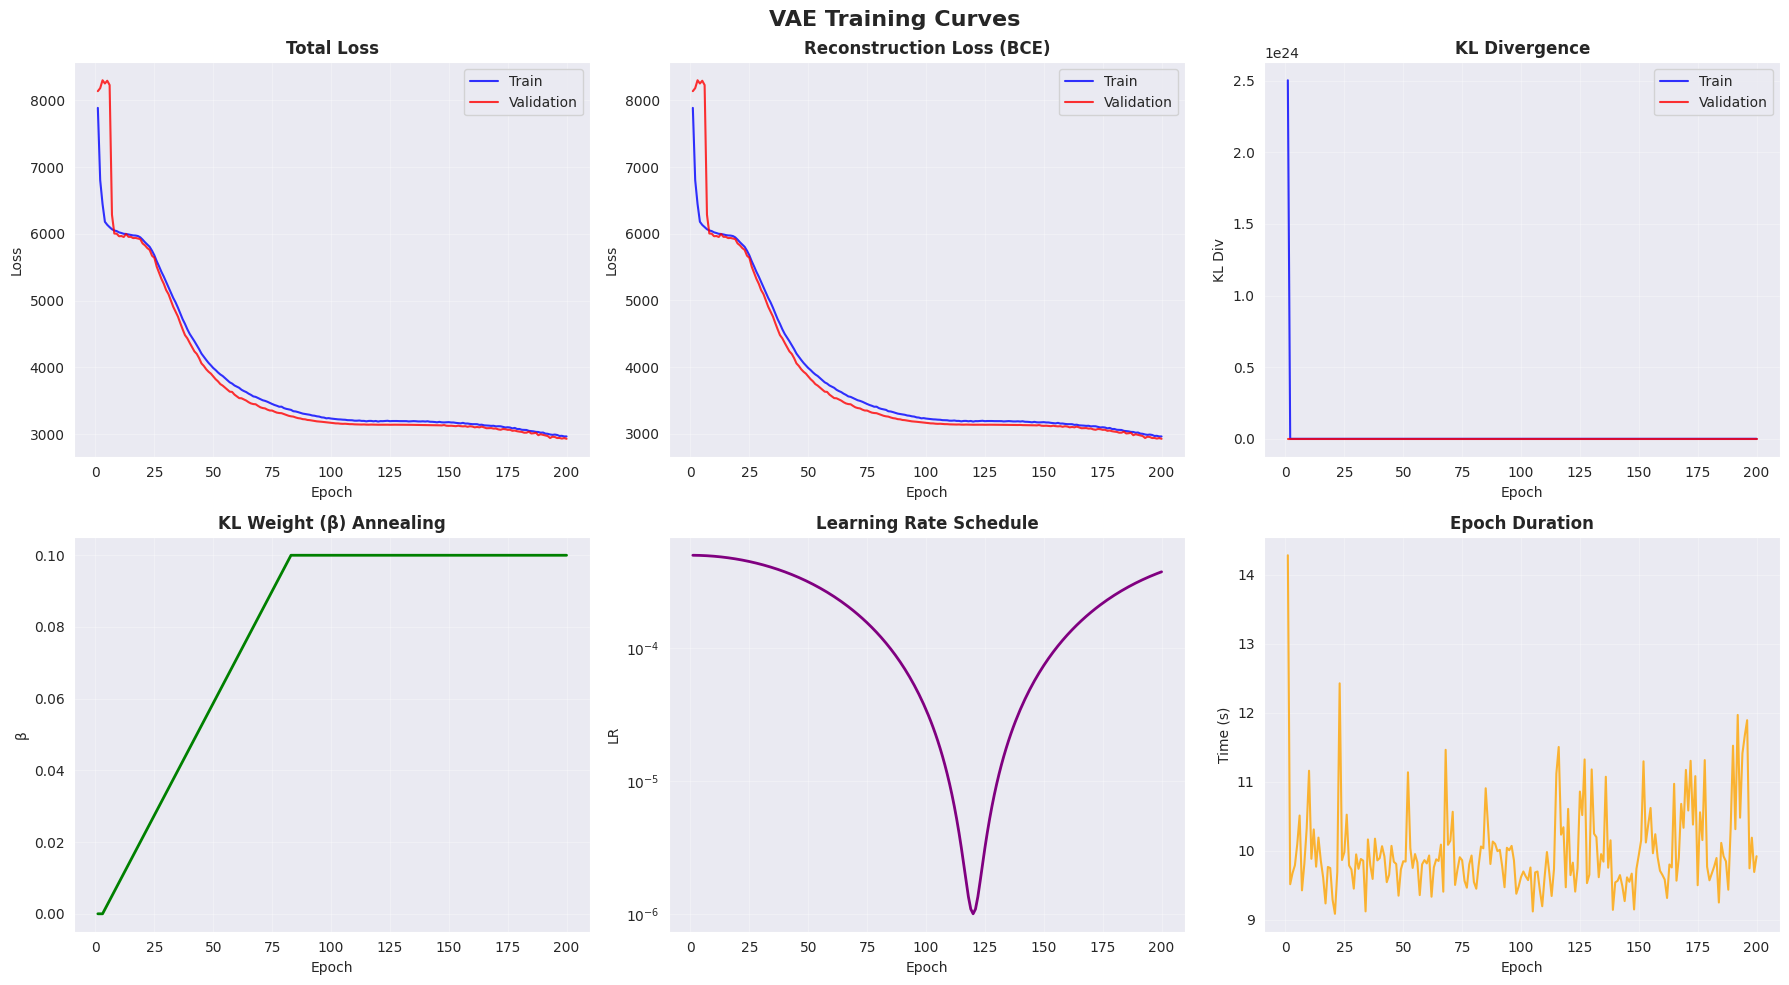

In [57]:
plot_training_curves(history, os.path.join(config.RESULTS_DIR, 'training_curves.png'))

In [58]:
@torch.no_grad()
def visualize_reconstructions(model, data_loader, device, num_images=8, save_path=None):
    """Show original vs reconstructed fingerprints"""
    model.eval()

    images, _ = next(iter(data_loader))
    images = images[:num_images].to(device)
    recon, _, _ = model(images)

    images_np = images.cpu().numpy()
    recon_np = recon.cpu().numpy()

    fig, axes = plt.subplots(2, num_images, figsize=(2.5 * num_images, 5))
    fig.suptitle('Original (top) vs Reconstructed (bottom)', fontsize=14, fontweight='bold')

    for i in range(num_images):
        axes[0, i].imshow(images_np[i, 0], cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel('Original', fontsize=12, fontweight='bold')

        axes[1, i].imshow(recon_np[i, 0], cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel('Recon', fontsize=12, fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


Loaded best model (epoch 200, val_loss: 2928.5510)


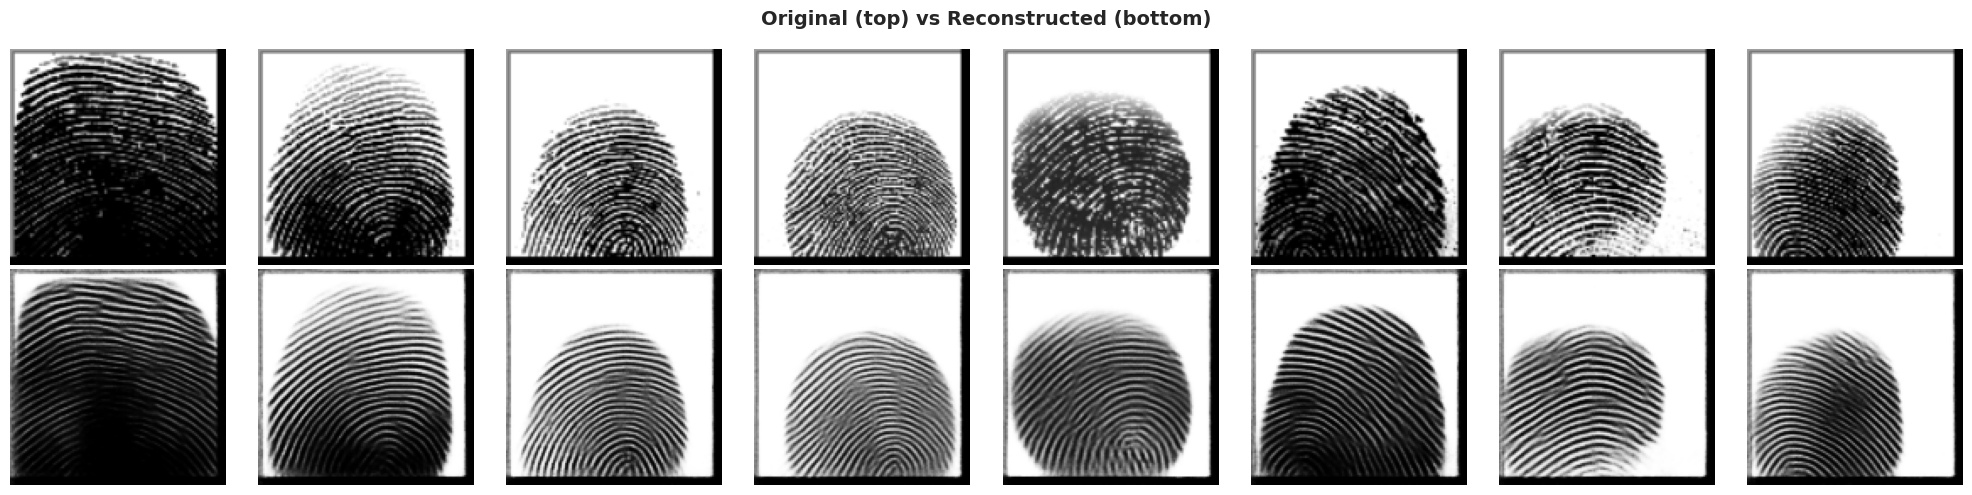

In [59]:
# Load best model for visualizations
best_path = os.path.join(config.CHECKPOINT_DIR, 'vae_best.pt')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Loaded best model (epoch {ckpt['epoch']}, val_loss: {ckpt['best_val_loss']:.4f})")

visualize_reconstructions(model, val_loader, DEVICE, num_images=8,
                         save_path=os.path.join(config.RESULTS_DIR, 'reconstructions.png'))

In [86]:
print("\n" + "=" * 70)
print("PART 1 COMPLETE — Model trained and saved to Google Drive!")
print(f"Best model: {best_path}")
print(f"Checkpoints: {config.CHECKPOINT_DIR}")
print(f"Results: {config.RESULTS_DIR}")
print(f"Split indices: {os.path.join(config.CHECKPOINT_DIR, 'data_split_indices.pt')}")
print("Proceed to Part 2 for evaluation & analysis")
print("=" * 70)

# List all saved files on Drive
print("\nFiles saved to Google Drive:")
for d in [config.CHECKPOINT_DIR, config.RESULTS_DIR]:
    if os.path.isdir(d):
        for f in sorted(os.listdir(d)):
            sz = os.path.getsize(os.path.join(d, f))
            print(f"{os.path.basename(d)}/{f} ({sz/1024:.1f} KB)")


PART 1 COMPLETE — Model trained and saved to Google Drive!
Best model: /content/drive/MyDrive/Colab_Notebooks/VAE/vae_fingerprints/checkpoints/vae_best.pt
Checkpoints: /content/drive/MyDrive/Colab_Notebooks/VAE/vae_fingerprints/checkpoints
Results: /content/drive/MyDrive/Colab_Notebooks/VAE/vae_fingerprints/results
Split indices: /content/drive/MyDrive/Colab_Notebooks/VAE/vae_fingerprints/checkpoints/data_split_indices.pt
Proceed to Part 2 for evaluation & analysis

Files saved to Google Drive:
checkpoints/data_split_indices.pt (18.7 KB)
checkpoints/vae_best.pt (139218.5 KB)
checkpoints/vae_best_history.json (39.7 KB)
checkpoints/vae_epoch_10.pt (139219.1 KB)
checkpoints/vae_epoch_100.pt (139219.3 KB)
checkpoints/vae_epoch_100_history.json (20.2 KB)
checkpoints/vae_epoch_10_history.json (2.2 KB)
checkpoints/vae_epoch_110.pt (139219.3 KB)
checkpoints/vae_epoch_110_history.json (22.2 KB)
checkpoints/vae_epoch_120.pt (139219.3 KB)
checkpoints/vae_epoch_120_history.json (24.1 KB)
checkpoi